In [210]:
import os
import pandas as pd
DIR = "../../results/experiment/nl2p_1/"
DIR2 = "../../results/archive/1001/nl2p_1/"

domain = {
    "cooking": "CT",
    "wikihow": "WHG",
    "win2k": "WHS"
}

ifae = []
for folder in os.listdir(DIR):
    if (folder in ['gemma3', 'gpt-4o-nano', 'gpt-4.1-nano', 'llama3.2']):
        continue
    folder_path = os.path.join(DIR, folder)
    if os.path.isdir(folder_path):
        for file in os.listdir(folder_path):
            if file.endswith(".csv"):
                file_path = os.path.join(folder_path, file)
                df = pd.read_csv(file_path)
                df['model'] = folder
                df['setting'] = 'action'
                df["solver"] = "IFAE"
                ifae.append(df)

ifae_df = pd.concat(ifae, ignore_index=True)
ifae_df['domain'] = ifae_df['dataset'].map(domain)
display(ifae_df)

,dataset,solver,model,Precision,Recall,F1,Object Precision,Object Recall,Object F1,setting,domain
0,wikihow,IFAE,gemma3_12b,0.641892,0.887436,0.744952,0.514943,0.453936,0.482519,action,WHG
1,win2k,IFAE,gemma3_12b,0.961444,0.877246,0.917417,0.864421,0.572985,0.689158,action,WHS
2,cooking,IFAE,gemma3_12b,0.790123,0.863804,0.825322,0.570871,0.623074,0.595831,action,CT
3,win2k,IFAE,gpt-4.1,0.945860,0.888556,0.916313,0.784693,0.500805,0.611402,action,WHS
4,wikihow,IFAE,gpt-4.1,0.730911,0.891811,0.803384,0.715214,0.514726,0.598630,action,WHG
5,cooking,IFAE,gpt-4.1,0.851312,0.841152,0.846202,0.698039,0.657709,0.677274,action,CT
6,win2k,IFAE,gpt-4.1-mini,0.971596,0.871161,0.918641,0.867322,0.579639,0.694882,action,WHS
7,wikihow,IFAE,gpt-4.1-mini,0.867565,0.745060,0.801659,0.670346,0.532377,0.593448,action,WHG
8,cooking,IFAE,gpt-4.1-mini,0.927291,0.771973,0.842534,0.650504,0.635106,0.642712,action,CT
9,wikihow,IFAE,gpt-4o,0.806871,0.739857,0.771912,0.683115,0.481601,0.564925,action,WHG


In [211]:
df_ifae = ifae_df[["solver", "domain", "model", "F1", "Object F1"]]
display(df_ifae)
extra_data = [
    ["WHS", "cEASDRL", "none", 0.9275, 0.925],
    ["CT", "cEASDRL", "none", 0.852, 0.765],
    ["WHG", "cEASDRL", "none", 0.7843, 0.771],
    ["WHS", "cEASDRL*", "none", 0.8393, 0.8008],
    ["CT", "cEASDRL*", "none", 0.7883, 0.665],
    ["WHG", "cEASDRL*", "none", 0.7174, 0.686]
]
df_ceasdrl = pd.DataFrame(extra_data, columns=["domain", "solver", "model", "F1", "Object F1"])
display(df_ceasdrl)

DIR = "../../results/experiment/gpt3_to_plan/"

gpt3 = []
for folder in os.listdir(DIR):
    if (folder in ['gemma3', 'gpt-4o-nano', 'gpt-4.1-nano', 'llama3.2']):
        continue
    folder_path = os.path.join(DIR, folder)
    if os.path.isdir(folder_path):
        for file in os.listdir(folder_path):
            if file.endswith(".csv"):
                file_path = os.path.join(folder_path, file)
                df = pd.read_csv(file_path)
                df['model'] = folder
                df['setting'] = 'action'
                df["solver"] = "GPT3-to-plan"
                gpt3.append(df)

gpt3_df = pd.concat(gpt3, ignore_index=True)
gpt3_df['domain'] = gpt3_df['dataset'].map(domain)

df_gpt3 = gpt3_df[["solver", "domain", "model", "F1", "Object F1"]]
display(df_gpt3)

,solver,domain,model,F1,Object F1
0,IFAE,WHG,gemma3_12b,0.744952,0.482519
1,IFAE,WHS,gemma3_12b,0.917417,0.689158
2,IFAE,CT,gemma3_12b,0.825322,0.595831
3,IFAE,WHS,gpt-4.1,0.916313,0.611402
4,IFAE,WHG,gpt-4.1,0.803384,0.598630
5,IFAE,CT,gpt-4.1,0.846202,0.677274
6,IFAE,WHS,gpt-4.1-mini,0.918641,0.694882
7,IFAE,WHG,gpt-4.1-mini,0.801659,0.593448
8,IFAE,CT,gpt-4.1-mini,0.842534,0.642712
9,IFAE,WHG,gpt-4o,0.771912,0.564925


,domain,solver,model,F1,Object F1
0,WHS,cEASDRL,none,0.9275,0.9250
1,CT,cEASDRL,none,0.8520,0.7650
2,WHG,cEASDRL,none,0.7843,0.7710
3,WHS,cEASDRL*,none,0.8393,0.8008
4,CT,cEASDRL*,none,0.7883,0.6650
5,WHG,cEASDRL*,none,0.7174,0.6860


,solver,domain,model,F1,Object F1
0,GPT3-to-plan,WHS,gemma3_12b,0.945660,0.682396
1,GPT3-to-plan,WHG,gemma3_12b,0.505300,0.470638
2,GPT3-to-plan,CT,gemma3_12b,0.824677,0.598170
3,GPT3-to-plan,CT,gpt-4.1,0.731158,0.522799
4,GPT3-to-plan,WHG,gpt-4.1,0.478233,0.432366
5,GPT3-to-plan,WHS,gpt-4.1,0.936765,0.516569
6,GPT3-to-plan,WHS,gpt-4.1-mini,0.934863,0.499628
7,GPT3-to-plan,CT,gpt-4.1-mini,0.801147,0.497371
8,GPT3-to-plan,WHG,gpt-4.1-mini,0.704424,0.439456
9,GPT3-to-plan,WHS,gpt-4o,0.948737,0.601482


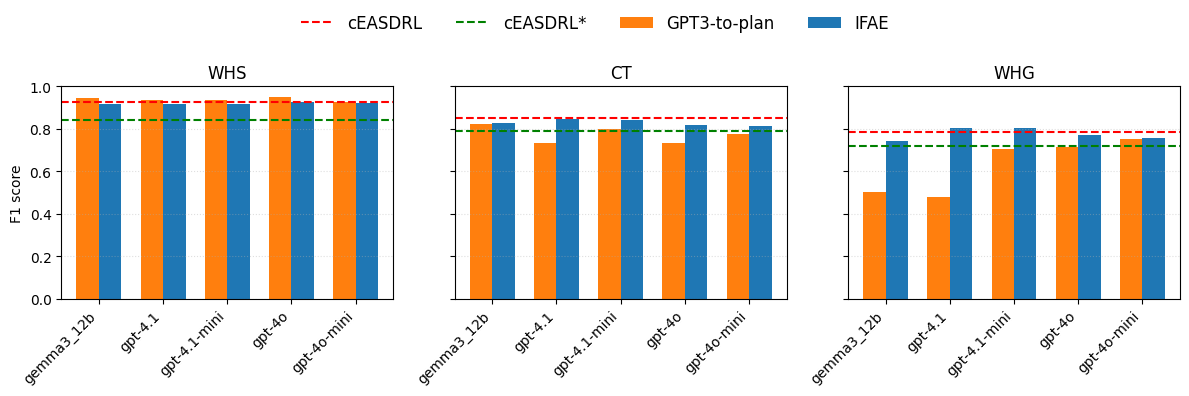

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

domains = ["WHS", "CT", "WHG"]

# Select models that appear in both GPT3-to-plan and IFAE
models = sorted(
    set(df_ifae["model"]).intersection(df_gpt3["model"])
)

bar_width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

for ax, domain in zip(axes, domains):

    ifae_sub = df_ifae[df_ifae["domain"] == domain]
    gpt3_sub = df_gpt3[df_gpt3["domain"] == domain]

    x = np.arange(len(models))

    # ===== Bars =====
    ifae_vals = [
        ifae_sub[ifae_sub["model"] == m]["F1"].values[0]
        for m in models
    ]
    gpt3_vals = [
        gpt3_sub[gpt3_sub["model"] == m]["F1"].values[0]
        for m in models
    ]

    ax.bar(
        x - bar_width/2,
        gpt3_vals,
        bar_width,
        label="GPT3-to-plan",
        color="tab:orange"
    )
    ax.bar(
        x + bar_width/2,
        ifae_vals,
        bar_width,
        label="IFAE",
        color="tab:blue"
    )

    # ===== cEASDRL baselines (horizontal lines) =====
    for solver, style, color in [("cEASDRL", "--", "red"), ("cEASDRL*", "--", "green")]:
        row = df_ceasdrl[
            (df_ceasdrl["solver"] == solver) &
            (df_ceasdrl["domain"] == domain)
        ]
        if not row.empty:
            ax.axhline(
                row["F1"].values[0],
                linestyle=style,
                color=color,
                linewidth=1.5,
                label=solver
            )

    # ===== Cosmetics =====
    ax.set_title(domain)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=90, ha="center", va="center")
    ax.set_ylim(0, 1.0)
    ax.grid(axis="y", linestyle=":", alpha=0.4)

axes[0].set_ylabel("F1 score")

# Deduplicate legend entries
handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
fig.legend(
    by_label.values(),
    by_label.keys(),
    loc="upper center",
    ncol=4,
    frameon=False,
    fontsize=12
)

plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.show()


,dataset,solver,model,Precision,Recall,F1,Object Precision,Object Recall,Object F1,setting,domain
0,wikihow,nl2p,gemma3_12b,0.641892,0.887436,0.744952,0.514943,0.453936,0.482519,action,WHG
1,win2k,nl2p,gemma3_12b,0.961444,0.877246,0.917417,0.864421,0.572985,0.689158,action,WHS
2,cooking,nl2p,gemma3_12b,0.790123,0.863804,0.825322,0.570871,0.623074,0.595831,action,CT
3,win2k,nl2p,gpt-4.1,0.945860,0.888556,0.916313,0.784693,0.500805,0.611402,action,WHS
4,wikihow,nl2p,gpt-4.1,0.730911,0.891811,0.803384,0.715214,0.514726,0.598630,action,WHG
5,cooking,nl2p,gpt-4.1,0.851312,0.841152,0.846202,0.698039,0.657709,0.677274,action,CT
6,win2k,nl2p,gpt-4.1-mini,0.971596,0.871161,0.918641,0.867322,0.579639,0.694882,action,WHS
7,wikihow,nl2p,gpt-4.1-mini,0.867565,0.745060,0.801659,0.670346,0.532377,0.593448,action,WHG
8,cooking,nl2p,gpt-4.1-mini,0.927291,0.771973,0.842534,0.650504,0.635106,0.642712,action,CT
9,wikihow,nl2p,gpt-4o,0.806871,0.739857,0.771912,0.683115,0.481601,0.564925,action,WHG


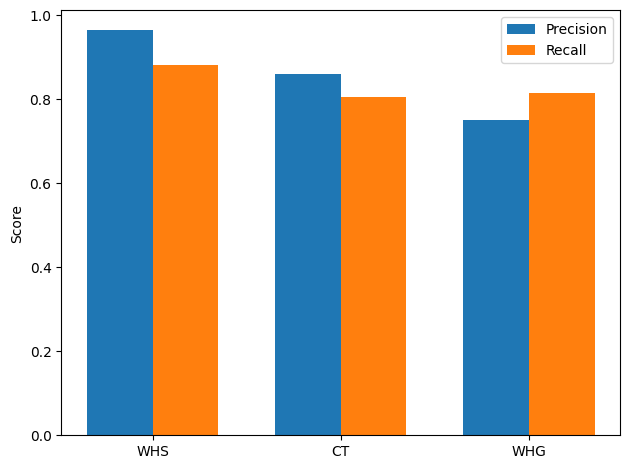

In [170]:
import pandas as pd
import matplotlib.pyplot as plt

DIR = "../../results/experiment/nl2p_1/"
DIR2 = "../../results/archive/1001/nl2p_1/"

domain = {
    "cooking": "CT",
    "wikihow": "WHG",
    "win2k": "WHS"
}

action_results = []
for folder in os.listdir(DIR):
    if (folder in ['gemma3', 'gpt-4o-nano', 'gpt-4.1-nano', 'llama3.2']):
        continue
    folder_path = os.path.join(DIR, folder)
    if os.path.isdir(folder_path):
        for file in os.listdir(folder_path):
            if file.endswith(".csv"):
                file_path = os.path.join(folder_path, file)
                df = pd.read_csv(file_path)
                df['model'] = folder
                df['setting'] = 'action'
      
                action_results.append(df)

action_df = pd.concat(action_results, ignore_index=True)
action_df['domain'] = action_df['dataset'].map(domain)
display(action_df)

avg = action_df.groupby("domain")[["Precision", "Recall"]].mean().reset_index()
order = ["WHS", "CT", "WHG"]

avg = avg.set_index("domain").loc[order].reset_index()



# Plot grouped bar chart
x = range(len(avg))
width = 0.35

plt.figure()
plt.bar([i - width / 2 for i in x], avg["Precision"], width, label="Precision")
plt.bar([i + width / 2 for i in x], avg["Recall"], width, label="Recall")

plt.xticks(x, avg["domain"])
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()

In [171]:
def load_raw(DIR):
    domain_map = {
        "cooking": "CT",
        "wikihow": "WHG",
        "win2k": "WHS"
    }

    rows = []
    for folder in os.listdir(DIR):
        if folder in ['gemma3', 'gpt-4o-nano', 'gpt-4.1-nano', 'llama3.2']:
            continue
        folder_path = os.path.join(DIR, folder)
        if os.path.isdir(folder_path):
            for file in os.listdir(folder_path):
                if file.endswith(".csv"):
                    df = pd.read_csv(os.path.join(folder_path, file))
                    df["model"] = folder
                    rows.append(df)

    df = pd.concat(rows, ignore_index=True)
    df["domain"] = df["dataset"].map(domain_map)

    # average only over runs, NOT models
    df = (
        df.groupby(["domain", "model"])[["Precision", "Recall"]]
        .mean()
        .reset_index()
    )
    return df


In [172]:
base = load_raw("../../results/experiment/nl2p_1/")
excl = load_raw("../../results/exclude_construction/")

diff = excl.merge(
    base,
    on=["domain", "model"],
    suffixes=("_excl", "_base")
)

diff["Δ Precision"] = diff["Precision_excl"] - diff["Precision_base"]
diff["Δ Recall"] = diff["Recall_excl"] - diff["Recall_base"]


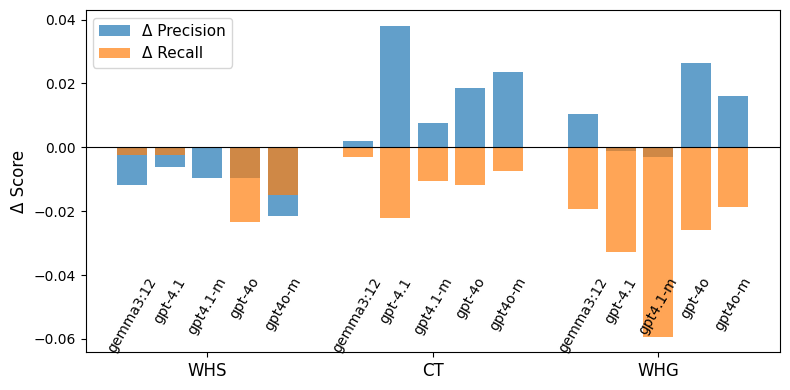

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

model_rename = {
    "gpt4.1": "gpt4.1",
    "gpt-4.1-mini": "gpt4.1-m",
    "gpt4o": "gpt4o",
    "gpt-4o-mini": "gpt4o-m",
    "gemma3_12b": "gemma3:12"
}


domains = ["WHS", "CT", "WHG"]
diff["model"] = diff["model"].map(model_rename).fillna(diff["model"])
models = diff["model"].unique()



bar_width = 0.12
group_gap = 0.9

fig, ax = plt.subplots(figsize=(8, 4))

# Keep track of x positions and labels for annotation
label_y = -0.065   # vertical position for model labels

for d_idx, domain in enumerate(domains):
    sub = diff[diff["domain"] == domain]

    base_x = d_idx * group_gap
    offsets = np.linspace(
        -bar_width * len(models) / 2,
        bar_width * len(models) / 2,
        len(models)
    )

    for i, model in enumerate(models):
        row = sub[sub["model"] == model]
        if row.empty:
            continue

        x = base_x + offsets[i]

        # Bars
        ax.bar(
            x,
            row["Δ Precision"].values[0],
            bar_width,
            color="tab:blue",
            alpha=0.7,
            label="Δ Precision" if (d_idx == 0 and i == 0) else "_nolegend_"
        )
        ax.bar(
            x,
            row["Δ Recall"].values[0],
            bar_width,
            color="tab:orange",
            alpha=0.7,
            label="Δ Recall" if (d_idx == 0 and i == 0) else "_nolegend_"
        )

        # Model name under each bar
        ax.text(
            x,
            label_y + 0.025,
            model,
            rotation=60,
            ha="center",
            va="top",
            fontsize=10
        )

# Cosmetics
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks([i * group_gap for i in range(len(domains))])
ax.set_xticklabels(domains, fontsize=12)
ax.set_ylabel("Δ Score", fontsize=12)

# Make space for model labels
ax.set_ylim(label_y - 0.005, ax.get_ylim()[1])

ax.legend(fontsize=11, loc="upper left")
plt.tight_layout()
plt.show()


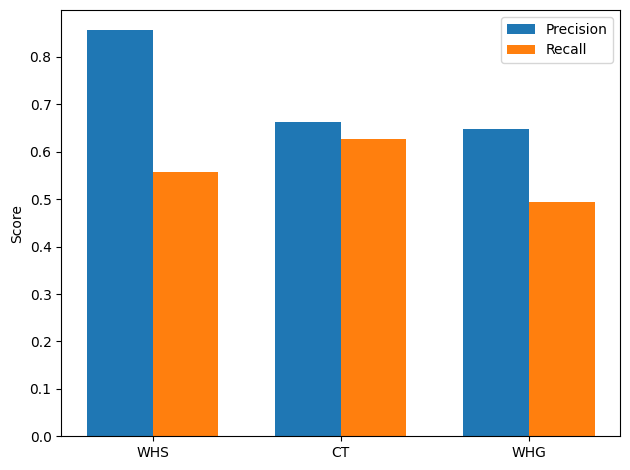

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
avg = action_df.groupby("domain")[["Object Precision", "Object Recall"]].mean().reset_index()
order = ["WHS", "CT", "WHG"]

avg = avg.set_index("domain").loc[order].reset_index()



# Plot grouped bar chart
x = range(len(avg))
width = 0.35

plt.figure()
plt.bar([i - width / 2 for i in x], avg["Object Precision"], width, label="Precision")
plt.bar([i + width / 2 for i in x], avg["Object Recall"], width, label="Recall")

plt.xticks(x, avg["domain"])
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()

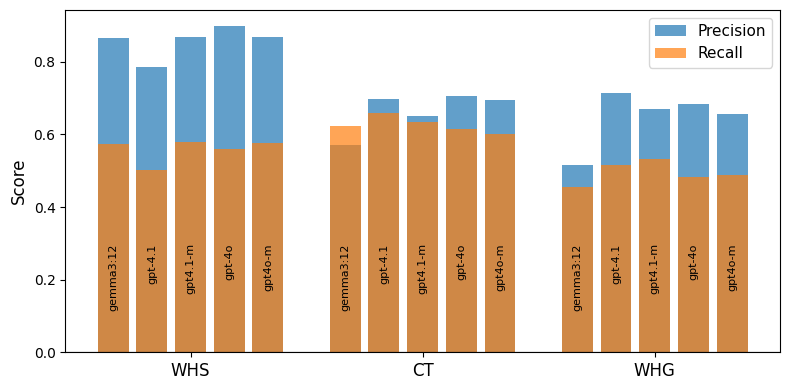

In [184]:
import numpy as np
import matplotlib.pyplot as plt

order = ["WHS", "CT", "WHG"]

df = (
    action_df
    .groupby(["domain", "model"])[["Object Precision", "Object Recall"]]
    .mean()
    .reset_index()
)

df["domain"] = pd.Categorical(df["domain"], categories=order, ordered=True)
df = df.sort_values("domain")

df["model"] = df["model"].map(model_rename).fillna(df["model"])


domains = order
models = df["model"].unique()

bar_width = 0.12
group_gap = 0.9

fig, ax = plt.subplots(figsize=(8, 4))

for d_idx, domain in enumerate(domains):
    sub = df[df["domain"] == domain]

    base_x = d_idx * group_gap
    offsets = np.linspace(
        -bar_width * len(models) / 2,
        bar_width * len(models) / 2,
        len(models)
    )

    for i, model in enumerate(models):
        row = sub[sub["model"] == model]
        if row.empty:
            continue

        x = base_x + offsets[i]

        ax.bar(
            x,
            row["Object Precision"].values[0],
            bar_width,
            color="tab:blue",
            alpha=0.7,
            label="Precision" if (d_idx == 0 and i == 0) else "_nolegend_"
        )
        ax.bar(
            x,
            row["Object Recall"].values[0],
            bar_width,
            color="tab:orange",
            alpha=0.7,
            label="Recall" if (d_idx == 0 and i == 0) else "_nolegend_"
        )

        # model label under bar
        ax.text(
            x,
            0.3,
            model,
            rotation=90,
            ha="center",
            va="top",
            fontsize=8
        )

# Axes & legend
ax.set_xticks([i * group_gap for i in range(len(domains))])
ax.set_xticklabels(domains, fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.axhline(0, color="black", linewidth=0.8)

ax.legend(fontsize=11, loc="upper right")

# leave space for model labels
ax.set_ylim()

plt.tight_layout()
plt.show()



In [135]:
DIR = "../../results/experiment/nl2p_1/"
DIR2 = "../../results/archive/1001/nl2p_1/"

domain = {
    "cooking": "CT",
    "wikihow": "WHG",
    "win2k": "WHS"
}

action_results = []
for folder in os.listdir(DIR):
    if (folder in ['gemma3', 'gpt-4o-nano', 'gpt-4.1-nano', 'llama3.2']):
        continue
    folder_path = os.path.join(DIR, folder)
    if os.path.isdir(folder_path):
        for file in os.listdir(folder_path):
            if file.endswith(".csv"):
                file_path = os.path.join(folder_path, file)
                df = pd.read_csv(file_path)
                df['model'] = folder
                df['setting'] = 'IFAE'
      
                action_results.append(df)


DIR = "../../results/experiment/nl2p_2/"

for folder in os.listdir(DIR):
    if (folder in ['gemma3', 'gpt-4o-nano', 'gpt-4.1-nano', 'llama3.2']):
        continue
    folder_path = os.path.join(DIR, folder)
    if os.path.isdir(folder_path):
        for file in os.listdir(folder_path):
            if file.endswith(".csv"):
                file_path = os.path.join(folder_path, file)
                df = pd.read_csv(file_path)
                df['model'] = folder
                df['setting'] = 'IFAE-2'
      
                action_results.append(df)

DIR = "../../results/experiment/nl2p_3/"

for folder in os.listdir(DIR):
    if (folder in ['gemma3', 'gpt-4o-nano', 'gpt-4.1-nano', 'llama3.2']):
        continue
    folder_path = os.path.join(DIR, folder)
    if os.path.isdir(folder_path):
        for file in os.listdir(folder_path):
            if file.endswith(".csv"):
                file_path = os.path.join(folder_path, file)
                df = pd.read_csv(file_path)
                df['model'] = folder
                df['setting'] = 'IFAE-3'
      
                action_results.append(df)

all_df = pd.concat(action_results, ignore_index=True)
all_df['domain'] = all_df['dataset'].map(domain)
display(all_df)

,dataset,solver,model,Precision,Recall,F1,Object Precision,Object Recall,Object F1,setting,domain
0,wikihow,nl2p,gemma3_12b,0.641892,0.887436,0.744952,0.514943,0.453936,0.482519,IFAE,WHG
1,win2k,nl2p,gemma3_12b,0.961444,0.877246,0.917417,0.864421,0.572985,0.689158,IFAE,WHS
2,cooking,nl2p,gemma3_12b,0.790123,0.863804,0.825322,0.570871,0.623074,0.595831,IFAE,CT
3,win2k,nl2p,gpt-4.1,0.945860,0.888556,0.916313,0.784693,0.500805,0.611402,IFAE,WHS
4,wikihow,nl2p,gpt-4.1,0.730911,0.891811,0.803384,0.715214,0.514726,0.598630,IFAE,WHG
5,cooking,nl2p,gpt-4.1,0.851312,0.841152,0.846202,0.698039,0.657709,0.677274,IFAE,CT
6,win2k,nl2p,gpt-4.1-mini,0.971596,0.871161,0.918641,0.867322,0.579639,0.694882,IFAE,WHS
7,wikihow,nl2p,gpt-4.1-mini,0.867565,0.745060,0.801659,0.670346,0.532377,0.593448,IFAE,WHG
8,cooking,nl2p,gpt-4.1-mini,0.927291,0.771973,0.842534,0.650504,0.635106,0.642712,IFAE,CT
9,wikihow,nl2p,gpt-4o,0.806871,0.739857,0.771912,0.683115,0.481601,0.564925,IFAE,WHG


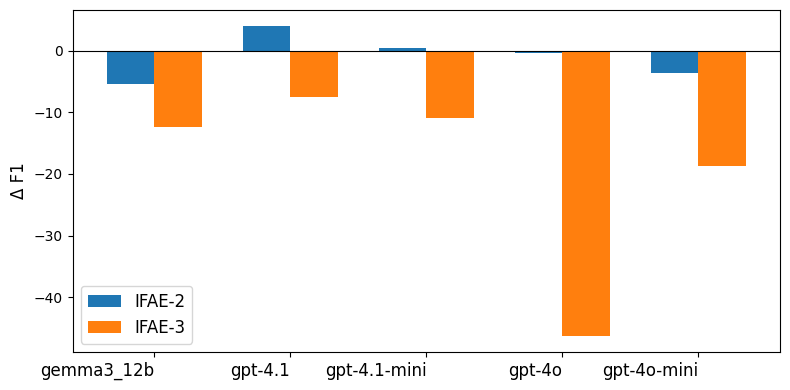

In [136]:
domains = ["CT", "WHG", "WHS"]
table = (
    all_df.pivot_table(
        index=["setting", "model"],
        columns="domain",
        values="Object F1",
        aggfunc="mean"   # safe even if duplicates exist
    )
    .reset_index()
)

df_long = table.melt(
    id_vars=["setting", "model"],
    value_vars=["CT", "WHG", "WHS"],
    var_name="dataset",
    value_name="F1"
)

avg_df = (
    df_long
    .groupby(["setting", "model"], as_index=False)["F1"]
    .mean()
)
pivot = avg_df.pivot(
    index="model",
    columns="setting",
    values="F1"
)

diff = (
    pivot.sub(pivot["IFAE"], axis=0)
         .div(pivot["IFAE"], axis=0)
         .mul(100)
)
diff = diff.drop(columns=["IFAE"])

fig, ax = plt.subplots(figsize=(8, 4))

diff.plot(
    kind="bar",
    ax=ax,
    width=0.7
)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Δ F1", fontsize=12)
ax.set_xlabel("")

plt.xticks(rotation=0, ha="right", fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

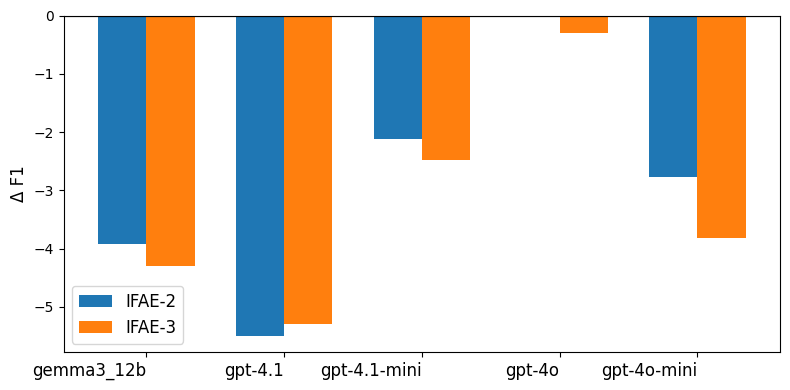

In [137]:
table = (
    all_df.pivot_table(
        index=["setting", "model"],
        columns="domain",
        values="F1",
        aggfunc="mean"   # safe even if duplicates exist
    )
    .reset_index()
)

df_long = table.melt(
    id_vars=["setting", "model"],
    value_vars=["CT", "WHG", "WHS"],
    var_name="dataset",
    value_name="F1"
)

avg_df = (
    df_long
    .groupby(["setting", "model"], as_index=False)["F1"]
    .mean()
)
pivot = avg_df.pivot(
    index="model",
    columns="setting",
    values="F1"
)

diff = (
    pivot.sub(pivot["IFAE"], axis=0)
         .div(pivot["IFAE"], axis=0)
         .mul(100)
)
diff = diff.drop(columns=["IFAE"])

fig, ax = plt.subplots(figsize=(8, 4))

diff.plot(
    kind="bar",
    ax=ax,
    width=0.7
)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Δ F1", fontsize=12)
ax.set_xlabel("")

plt.xticks(rotation=0, ha="right", fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

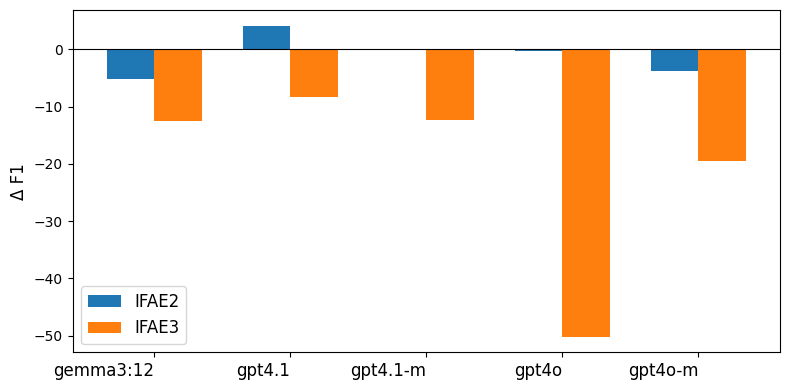

In [138]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===== Raw table data =====
data = [
    # IFAE
    ("IFAE",  "gpt4.1-m", 62.89, 59.25, 69.88),
    ("IFAE",  "gpt4.1",   66.72, 59.52, 61.57),
    ("IFAE",  "gpt4o-m",  63.15, 55.98, 69.65),
    ("IFAE",  "gpt4o",    63.44, 56.00, 68.72),
    ("IFAE",  "gemma3:12",59.09, 48.21, 69.30),

    # IFAE-2
    ("IFAE2", "gpt4.1-m", 66.37, 58.00, 67.66),
    ("IFAE2", "gpt4.1",   66.56, 58.86, 70.17),
    ("IFAE2", "gpt4o-m",  64.94, 53.24, 63.58),
    ("IFAE2", "gpt4o",    65.60, 54.96, 66.90),
    ("IFAE2", "gemma3:12",58.72, 46.24, 62.56),

    # IFAE-3
    ("IFAE3", "gpt4.1-m", 60.16, 51.93, 56.25),
    ("IFAE3", "gpt4.1",   61.00, 52.26, 58.87),
    ("IFAE3", "gpt4o-m",  57.50, 46.73, 47.72),
    ("IFAE3", "gpt4o",    48.96, 28.45, 16.29),
    ("IFAE3", "gemma3:12",59.64, 47.83, 46.93),
]

df = pd.DataFrame(
    data,
    columns=["setting", "model", "CT", "WHG", "WHS"]
)

domains = ["CT", "WHG", "WHS"]

df_long = df.melt(
    id_vars=["setting", "model"],
    value_vars=["CT", "WHG", "WHS"],
    var_name="dataset",
    value_name="F1"
)

avg_df = (
    df_long
    .groupby(["setting", "model"], as_index=False)["F1"]
    .mean()
)
pivot = avg_df.pivot(
    index="model",
    columns="setting",
    values="F1"
)

diff = (
    pivot.sub(pivot["IFAE"], axis=0)
         .div(pivot["IFAE"], axis=0)
         .mul(100)
)
diff = diff.drop(columns=["IFAE"])

fig, ax = plt.subplots(figsize=(8, 4))

diff.plot(
    kind="bar",
    ax=ax,
    width=0.7
)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Δ F1", fontsize=12)
ax.set_xlabel("")

plt.xticks(rotation=0, ha="right", fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()




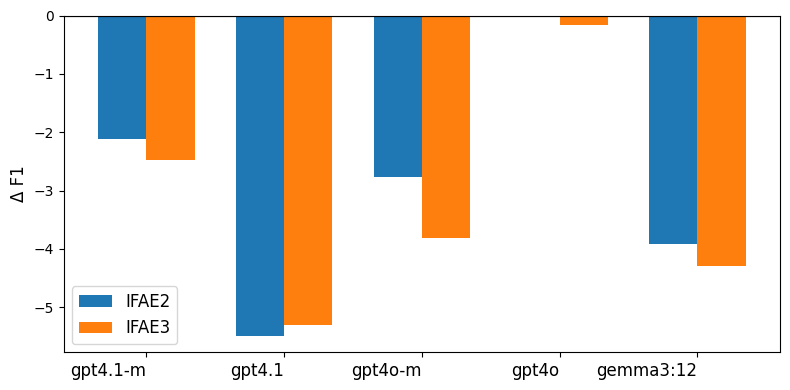

In [139]:
data_action = [
    # IFAE
    ("IFAE",  "gpt4.1-m", 84.25, 80.17, 91.86),
    ("IFAE",  "gpt4.1",   84.62, 80.34, 91.63),
    ("IFAE",  "gpt4o-m",  81.17, 75.64, 92.22),
    ("IFAE",  "gpt4o",    82.01, 77.19, 92.67),
    ("IFAE",  "gemma3:12",82.53, 74.50, 91.74),

    # IFAE-2
    ("IFAE2", "gpt4.1-m", 84.11, 76.26, 90.48),
    ("IFAE2", "gpt4.1",   82.19, 68.06, 92.24),
    ("IFAE2", "gpt4o-m",  79.48, 71.64, 91.03),
    ("IFAE2", "gpt4o",    83.59, 76.89, 91.31),
    ("IFAE2", "gemma3:12",80.15, 71.17, 87.69),

    # IFAE-3
    ("IFAE3", "gpt4.1-m", 83.62, 76.45, 89.86),
    ("IFAE3", "gpt4.1",   82.19, 68.35, 92.45),
    ("IFAE3", "gpt4o-m",  79.69, 70.96, 88.89),
    ("IFAE3", "gpt4o",    84.07, 76.21, 91.16),
    ("IFAE3", "gemma3:12",80.06, 71.66, 86.37),
]

df = pd.DataFrame(
    data_action,
    columns=["setting", "model", "CT", "WHG", "WHS"]
)

model_order = ["gpt4.1-m", "gpt4.1", "gpt4o-m", "gpt4o", "gemma3:12"]

domains = ["CT", "WHG", "WHS"]

df_long = df.melt(
    id_vars=["setting", "model"],
    value_vars=["CT", "WHG", "WHS"],
    var_name="dataset",
    value_name="F1"
)

avg_df = (
    df_long
    .groupby(["setting", "model"], as_index=False)["F1"]
    .mean()
)
pivot = avg_df.pivot(
    index="model",
    columns="setting",
    values="F1"
)

diff = (
    pivot.sub(pivot["IFAE"], axis=0)
         .div(pivot["IFAE"], axis=0)
         .mul(100)
)
diff = diff.drop(columns=["IFAE"])
diff = diff.reindex(model_order)

fig, ax = plt.subplots(figsize=(8, 4))

diff.plot(
    kind="bar",
    ax=ax,
    width=0.7
)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Δ F1", fontsize=12)
ax.set_xlabel("")

plt.xticks(rotation=0, ha="right", fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

In [140]:
import pandas as pd

data = [
    # NLP baselines
    ["cEASDRL",   92.75, 85.20, 78.43, 92.50, 76.50, 77.10],
    ["cEASDRL*",  83.93, 78.83, 71.74, 80.08, 66.58, 68.65],
    ["NaRuto",   70.46, 57.94, 54.33, 30.07, 31.91, 29.42],

    # GPT3-to-plan
    ["gpt4.1-n",  88.64, 19.39, 15.88, 46.54, 31.38,  3.62],
    ["gpt4.1-m",  93.48, 80.11, 70.44, 49.96, 49.74, 43.95],
    ["gpt4.1",    93.68, 73.12, 47.82, 51.65, 52.28, 43.24],
    ["gpt4o-m",   92.84, 77.74, 75.03, 55.71, 61.03, 49.62],
    ["gpt4o",     94.90, 73.52, 71.55, 60.15, 56.62, 47.66],
    ["gemma3:4",  91.98, 56.96, 12.47, 55.78, 54.87, 29.32],
    ["gemma3:12", 94.57, 82.47, 50.53, 68.24, 59.82, 47.06],
    ["llama3.2:3",41.51, 19.10, 29.86, 17.11, 11.70, 19.73],

    # IFAE
    ["IFAE gpt4.1-n", 89.33, 81.37, 75.49, 57.15, 64.98, 56.45],
    ["IFAE gpt4.1-m", 91.86, 84.25, 80.17, 69.49, 64.27, 59.34],
    ["IFAE gpt4.1",   91.63, 84.62, 80.30, 61.14, 67.73, 59.86],
    ["IFAE gpt4o-m",  92.22, 81.17, 75.64, 69.28, 64.49, 56.07],
    ["IFAE gpt4o",    92.67, 82.01, 77.19, 69.02, 65.64, 56.49],
    ["IFAE gemma3:4", 87.54, 77.45, 70.06, 56.83, 52.69, 41.26],
    ["IFAE gemma3:12",91.74, 82.53, 74.50, 68.92, 59.58, 48.25],
    ["IFAE llama3.2:3",80.20, 77.34, 72.02, 46.08, 48.12, 42.68],
]

columns = [
    "Model",
    "Action WHS", "Action CT", "Action WHG",
    "Argument WHS", "Argument CT", "Argument WHG"
]

df = pd.DataFrame(data, columns=columns)
df.to_excel("action_argument_f1.xlsx", index=False)


In [141]:
data = [
    ["cEASDRL",   92.75, 85.20, 78.43, 92.50, 76.50, 77.10],
    ["cEASDRL*",  83.93, 78.83, 71.74, 80.08, 66.58, 68.65],
    ["GPT3-to-plan", 93.89, 77.39, 63.07, 57.14, 55.90, 46.31],
    ["IFAE", 91.28, 82.01, 76.31, 65.78, 62.40, 53.55 ]
]
columns = [
    "Model",
    "Action WHS F1", "Action CT F1", "Action WHG F1",
    "Argument WHS F1", "Argument CT F1", "Argument WHG F1"
]
df = pd.DataFrame(data, columns=columns)



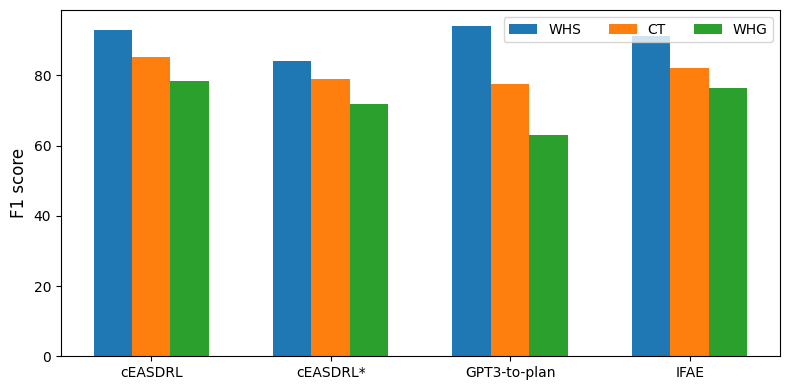

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

models = df["Model"].values

action_metrics = ["Action WHS F1", "Action CT F1", "Action WHG F1"]
action_vals = df[action_metrics].values

num_models = len(models)
x = np.arange(num_models) * 0.7
width = 0.15

fig, ax = plt.subplots(figsize=(8, 4))

for i, metric in enumerate(action_metrics):
    ax.bar(
        x + (i - 1) * width,
        action_vals[:, i],
        width,
        label=metric.replace("Action ", "").replace(" F1", "")
    )

ax.set_ylabel("F1 score", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=0)
ax.legend(ncol=3, fontsize=10)

plt.tight_layout()
plt.show()


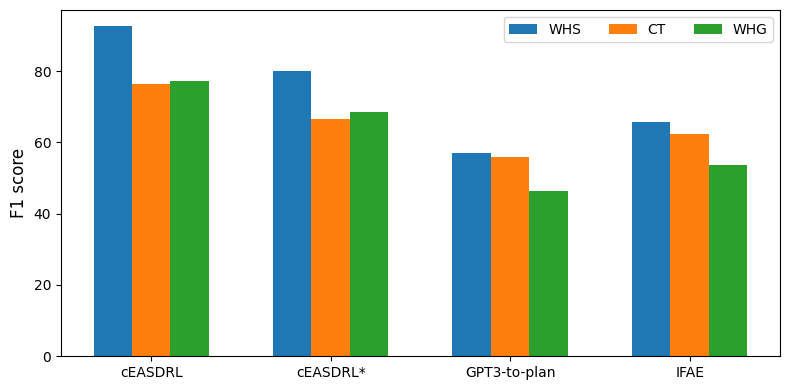

In [119]:
argument_metrics = ["Argument WHS F1", "Argument CT F1", "Argument WHG F1"]
argument_vals = df[argument_metrics].values

fig, ax = plt.subplots(figsize=(8, 4))

for i, metric in enumerate(argument_metrics):
    ax.bar(
        x + (i - 1) * width,
        argument_vals[:, i],
        width,
        label=metric.replace("Argument ", "").replace(" F1", "")
    )

ax.set_ylabel("F1 score", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=0)
ax.legend(ncol=3, fontsize=10)

plt.tight_layout()
plt.show()
